Imports:

In [26]:
from __future__ import annotations
from collections import defaultdict
from typing import (
    Dict,
    FrozenSet,
    Iterable,
    Optional,
    Tuple,
    Union,
)

import functools
import math
import numpy as np
import matplotlib.pyplot as plt
import itertools

from qiskit import QuantumCircuit
from qiskit.circuit.library import XXMinusYYGate, XXPlusYYGate
from qiskit.result import QuasiDistribution
from qiskit_nature.second_q.circuit.library import FermionicGaussianState
from qiskit_nature.second_q.hamiltonians import QuadraticHamiltonian
from qiskit_nature.second_q.operators import FermionicOp

Helper functions:

In [3]:
def orbital_combinations(
    n_modes: int, threshold: Optional[int] = None
) -> Iterable[tuple[int, ...]]:
    if threshold is None:
        threshold = n_modes
    yield ()
    yield tuple(range(n_modes))
    for i in range(threshold):
        yield (i,)
        yield tuple(range(i)) + tuple(range(i + 1, n_modes))

def orbital_permutations(n_modes: int) -> Iterable[tuple[int, ...]]:
    permutation = list(range(n_modes))
    for _ in range(math.ceil(n_modes / 2)):
        yield tuple(permutation)
        for i in range(0, n_modes - 1, 2):
            a, b = permutation[i], permutation[i + 1]
            permutation[i], permutation[i + 1] = b, a
        for i in range(1, n_modes - 1, 2):
            a, b = permutation[i], permutation[i + 1]
            permutation[i], permutation[i + 1] = b, a

def measurement_labels(n_modes: int) -> Iterable[tuple[tuple[int, ...], str]]:
    yield tuple(range(n_modes)), "number"
    for permutation in orbital_permutations(n_modes):
        yield permutation, "tunneling_plus_even"
        yield permutation, "tunneling_plus_odd"
        yield permutation, "tunneling_minus_even"
        yield permutation, "tunneling_minus_odd"
        yield permutation, "superconducting_plus_even"
        yield permutation, "superconducting_plus_odd"
        yield permutation, "superconducting_minus_even"
        yield permutation, "superconducting_minus_odd"

@functools.lru_cache
def kitaev_hamiltonian(
    n_modes: int,
    tunneling: float,
    superconducting: Union[float, complex],
    chemical_potential: float,
) -> QuadraticHamiltonian:
    eye = np.eye(n_modes)
    upper_diag = np.diag(np.ones(n_modes - 1), k=1)
    lower_diag = np.diag(np.ones(n_modes - 1), k=-1)
    hermitian_part = -tunneling * (upper_diag + lower_diag) + chemical_potential * eye
    antisymmetric_part = superconducting * (upper_diag - lower_diag)
    constant = -0.5 * chemical_potential * n_modes
    return QuadraticHamiltonian(
        hermitian_part=hermitian_part,
        antisymmetric_part=antisymmetric_part,
        constant=constant,
    )

def measure_interaction_op(circuit: QuantumCircuit, label: str) -> QuantumCircuit:
    if label == "number":
        circuit = circuit.copy()
        circuit.measure_all()
        return circuit
    if label.startswith("tunneling_plus"):
        gate = XXPlusYYGate(np.pi / 2, -np.pi / 2)
    elif label.startswith("tunneling_minus"):
        gate = XXPlusYYGate(np.pi / 2, -np.pi)
    elif label.startswith("superconducting_plus"):
        gate = XXMinusYYGate(np.pi / 2, -np.pi / 2)
    else:
        gate = XXMinusYYGate(np.pi / 2, -np.pi)
    if label.endswith("even"):
        start_index = 0
    else:
        start_index = 1
    circuit = circuit.copy()
    for i in range(start_index, circuit.num_qubits-1, 2):
        circuit.append(gate, [i, i+1])
    circuit.measure_all()
    return circuit

def _all_real_rz_gates(circuit: QuantumCircuit, rtol=1e-5, atol=1e-8) -> bool:
    for instruction in circuit.data:
        if isinstance(instruction.operation, XXPlusYYGate):
            _, beta = instruction.operation.params
            if not np.isclose(
                (beta + np.pi / 2) % np.pi, 0.0, rtol=rtol, atol=atol
            ) and not np.isclose((beta + np.pi / 2) % np.pi, np.pi, atol=1e-8):
                return False
    return True

Parameters:

In [4]:
n_modes = 3
tunneling_values = [-1.0]
superconducting_values = [1.0]
chemical_potential_values = list(np.linspace(0.0, 3.0, num=5))
occupied_orbitals_list = list(orbital_combinations(n_modes, threshold=2))

Circuit generation:

In [5]:
circuits = []
for (
    tunneling, 
    superconducting, 
    chemical_potential, 
    occupied_orbitals
) in itertools.product(
    tunneling_values, 
    superconducting_values, 
    chemical_potential_values, 
    occupied_orbitals_list
):
    for permutation, label in measurement_labels(n_modes):
        hamiltonian = kitaev_hamiltonian(
            n_modes,
            tunneling=tunneling,
            superconducting=superconducting,
            chemical_potential=chemical_potential,
        )
        transformation_matrix, _, _ = hamiltonian.diagonalizing_bogoliubov_transform()
        perm = np.array(permutation)
        full_permutation = np.concatenate([perm, perm+n_modes])
        for i in range(n_modes):
            transformation_matrix[i, :] = transformation_matrix[i, full_permutation]
        base_circuit = FermionicGaussianState(transformation_matrix, occupied_orbitals)
        if "_minus_" in label and _all_real_rz_gates(base_circuit, atol=1e-6):
            continue
        circuits.append(measure_interaction_op(base_circuit, label))
len(circuits)

270

Various helper functions I haven't used yet:

In [6]:
_CovarianceDict = Dict[FrozenSet[Tuple[int, int]], float]

def covariance(
    quasi_dist: QuasiDistribution, op1: str, op2: str
) -> float:
    """Compute covariance of two diagonal operators from quasiprobabilities."""
    expval1 = quasi_dist.expval(op1)
    expval2 = quasi_dist.expval(op2)
    cov = 0.0
    for bitstring, quasiprob in quasi_dist.items():
        cov += (
            quasiprob
            * (evaluate_diagonal_op(op1, bitstring) - expval1)
            * (evaluate_diagonal_op(op2, bitstring) - expval2)
        )
    return cov * quasi_dist.mitigation_overhead / quasi_dist.shots

def compute_interaction_matrix(
    quasis: dict[tuple[tuple[int, ...], str], QuasiDistribution],
    label: str,
) -> tuple[np.ndarray, _CovarianceDict]:
    n = len(next(iter(next(iter(quasis.values())))))
    mat = np.zeros((n, n))
    cov: _CovarianceDict = defaultdict(float)

    permutation = tuple(range(n))
    if (permutation, f"{label}_even") not in quasis and (
        permutation,
        f"{label}_odd",
    ) not in quasis:
        return mat, cov

    if label == "tunneling_plus":
        sign = -1
        symmetry = 1
    elif label == "tunneling_minus":
        sign = -1
        symmetry = -1
    elif label == "superconducting_plus":
        sign = 1
        symmetry = -1
    else:  # label == "superconducting_minus"
        sign = 1
        symmetry = -1
    for permutation in orbital_permutations(n):
        even_quasis = quasis[permutation, f"{label}_even"]
        odd_quasis = quasis[permutation, f"{label}_odd"]
        for start_index in [0, 1]:
            quasi_dist = odd_quasis if start_index else even_quasis
            for i in range(start_index, n - 1, 2):
                z0 = "I" * (n - i - 1) + "Z" + "I" * i
                z1 = "I" * (n - i - 2) + "Z" + "I" * (i + 1)
                z0_expval = quasi_dist.expval(z0)
                z1_expval = quasi_dist.expval(z1)
                val = 0.5 * (z1_expval + sign * z0_expval)
                p, q = permutation[i], permutation[i + 1]
                mat[p, q] = val
                mat[q, p] = symmetry * val
    for permutation in orbital_permutations(n):
        even_quasis = quasis[permutation, f"{label}_even"]
        odd_quasis = quasis[permutation, f"{label}_odd"]
        for start_index in [0, 1]:
            quasi_dist = odd_quasis if start_index else even_quasis
            for i in range(start_index, n - 1, 2):
                z0 = "I" * (n - i - 1) + "Z" + "I" * i
                z1 = "I" * (n - i - 2) + "Z" + "I" * (i + 1)
                p, q = permutation[i], permutation[i + 1]
                if p > q:
                    p, q = q, p
                for j in range(start_index, n - 1, 2):
                    z2 = "I" * (n - j - 1) + "Z" + "I" * j
                    z3 = "I" * (n - j - 2) + "Z" + "I" * (j + 1)
                    r, s = permutation[j], permutation[j + 1]
                    if r > s:
                        r, s = s, r
                    cov[frozenset([(p, q), (r, s)])] = 0.25 * (
                        covariance(quasi_dist, z0, z2)
                        + sign * covariance(quasi_dist, z0, z3)
                        + sign * covariance(quasi_dist, z1, z2)
                        + covariance(quasi_dist, z1, z3)
                    )
    return mat, cov

def compute_correlation_matrix(
    quasis: dict[tuple[tuple[int, ...], str], QuasiDistribution]
) -> tuple[np.ndarray, _CovarianceDict]:
    n = len(next(iter(next(iter(quasis.values())))))
    tunneling_plus, tunneling_plus_cov = compute_interaction_matrix(
        quasis, "tunneling_plus"
    )
    tunneling_minus, tunneling_minus_cov = compute_interaction_matrix(
        quasis, "tunneling_minus"
    )
    superconducting_plus, superconducting_plus_cov = compute_interaction_matrix(
        quasis, "superconducting_plus"
    )
    superconducting_minus, superconducting_minus_cov = compute_interaction_matrix(
        quasis, "superconducting_minus"
    )
    tunneling_mat = 0.5 * (tunneling_plus + 1j * tunneling_minus)
    superconducting_mat = 0.5 * (superconducting_plus + 1j * superconducting_minus)
    corr = np.block(
        [
            [tunneling_mat, superconducting_mat],
            [-superconducting_mat.conj(), np.eye(n) - tunneling_mat.T],
        ],
    )
    num_quasis = quasis[(tuple(range(n)), "number")]
    for i in range(n):
        num = "I" * (n - i - 1) + "1" + "I" * i
        expval = num_quasis.expval(num)
        corr[i, i] = expval
        corr[i + n, i + n] = 1 - expval
    cov: _CovarianceDict = defaultdict(float)
    for i in range(n):
        for j in range(i + 1, n):
            for k in range(n):
                for ell in range(k + 1, n):
                    cov[frozenset([(i, j), (k, ell)])] = 0.25 * (
                        tunneling_plus_cov[frozenset([(i, j), (k, ell)])]
                        + tunneling_minus_cov[frozenset([(i, j), (k, ell)])]
                    )
                    cov[frozenset([(i, j + n), (k, ell + n)])] = 0.25 * (
                        superconducting_plus_cov[frozenset([(i, j), (k, ell)])]
                        + superconducting_minus_cov[frozenset([(i, j), (k, ell)])]
                    )
    for i in range(n):
        z0 = "I" * (n - i - 1) + "Z" + "I" * i
        for j in range(i, n):
            z1 = "I" * (n - j - 1) + "Z" + "I" * j
            cov[frozenset([(i, i), (j, j)])] = 0.25 * covariance(num_quasis, z0, z1)
    return corr, cov

Helper functions for creating ideal graphs:

In [ ]:
def expectation_from_correlation_matrix(
    operator: Union[QuadraticHamiltonian, FermionicOp],
    corr: np.ndarray,
    cov: Optional[_CovarianceDict] = None,
) -> tuple[complex, float]:
    dim, _ = corr.shape
    n = dim // 2
    if isinstance(operator, QuadraticHamiltonian):
        exp_val = (
            np.sum(
                operator.hermitian_part * corr[:n, :n]
                + np.real(operator.antisymmetric_part * corr[:n, n:])
            )
            + operator.constant
        )
        var = 0 + 0j
        if cov is not None:
            for i in range(n):
                for j in range(i + 1, n):
                    for k in range(n):
                        for ell in range(k + 1, n):
                            var += 2 * np.real(
                                operator.hermitian_part[i, j]
                                * operator.hermitian_part[k, ell]
                                * cov[frozenset([(i, j), (k, ell)])]
                            )
                            var += 2 * np.real(
                                operator.hermitian_part[i, j]
                                * operator.hermitian_part[k, ell].conjugate()
                                * cov[frozenset([(i, j), (k, ell)])]
                            )
                            var += 2 * np.real(
                                operator.antisymmetric_part[i, j]
                                * operator.antisymmetric_part[k, ell]
                                * cov[frozenset([(i, j + n), (k, ell + n)])]
                            )
                            var += 2 * np.real(
                                operator.antisymmetric_part[i, j]
                                * operator.antisymmetric_part[k, ell].conjugate()
                                * cov[frozenset([(i, j + n), (k, ell + n)])]
                            )
            for i in range(n):
                for j in range(i, n):
                    var += (1 + (i != j)) * (
                        operator.hermitian_part[i, i]
                        * operator.hermitian_part[j, j]
                        * cov[frozenset([(i, i), (j, j)])]
                    )
    else:  # isinstance(operator, FermionicOp)
        exp_val = 0.0
        for term, coeff in operator.terms():
            if not term:
                exp_val += coeff
            elif len(term) == 2:
                (action_i, i), (action_j, j) = term
                exp_val += (
                    coeff * corr[i + n * (action_i == "-"), j + n * (action_j == "+")]
                )
            else:
                raise ValueError(
                    "Operator must be quadratic in the fermionic ladder operators."
                )
        var = 0 + 0j
        if cov is not None:
            for term_ij, coeff_ij in operator.terms():
                if not term_ij:
                    continue
                (action_i, i), (action_j, j) = term_ij
                sign_ij = 1
                if i > j:
                    i, j = j, i
                    action_i, action_j = action_j, action_i
                    sign_ij *= -1
                if action_i == "-":
                    sign_ij *= -1
                for term_kl, coeff_kl in operator.terms():
                    if not term_kl:
                        continue
                    (action_k, k), (action_l, ell) = term_kl
                    sign_kl = 1
                    if k > ell:
                        k, ell = ell, k
                        action_k, action_l = action_l, action_k
                        sign_kl = -1
                    if action_k == "-":
                        sign_kl *= -1
                    var += (
                        coeff_ij
                        * coeff_kl.conjugate()
                        * sign_ij
                        * sign_kl
                        * cov[
                            frozenset(
                                [
                                    (i, j + n * (action_i == action_j)),
                                    (k, ell + n * (action_k == action_l)),
                                ]
                            )
                        ]
                    )
    return exp_val, np.sqrt(np.real(var))

def majorana_op(index: int, action: int) -> FermionicOp:
    if action == 0:
        return FermionicOp({f"-_{index}": 1.0}) + FermionicOp({f"+_{index}": 1.0})
    return -1j * (FermionicOp({f"-_{index}": 1.0}) - FermionicOp({f"+_{index}": 1.0}))

def site_correlation_op(site: int) -> FermionicOp:
    return 1j * majorana_op(0, 0) @ majorana_op(site // 2, site % 2)

def edge_correlation_op(n_modes: int) -> FermionicOp:
    return site_correlation_op(2 * n_modes - 1)

@functools.lru_cache
def diagonalizing_bogoliubov_transform(
    n_modes: int,
    tunneling: float,
    superconducting: Union[float, complex],
    chemical_potential: float,
) -> tuple[np.ndarray, np.ndarray, float]:
    return kitaev_hamiltonian(
        n_modes,
        tunneling=tunneling,
        superconducting=superconducting,
        chemical_potential=chemical_potential,
    ).diagonalizing_bogoliubov_transform()

Creation of ideal data:

In [49]:
start = chemical_potential_values[0]
if start == 0:
    start = 1e-8
chemical_potential_values = np.linspace(
    start,
    chemical_potential_values[-1],
    num=50,
)

edge_correlation = edge_correlation_op(n_modes)
energy_exact = defaultdict(list)  # dict[tuple[int, ...], list[float]]
edge_correlation_exact = defaultdict(list)  # dict[tuple[int, ...], list[float]]
parity_exact = defaultdict(list)  # dict[tuple[int, ...], list[float]]
number_exact = defaultdict(list)  # dict[tuple[int, ...], list[float]]

data = {}
for chemical_potential in chemical_potential_values:
    (
        transformation_matrix,
        orbital_energies,
        constant,
    ) = diagonalizing_bogoliubov_transform(
        n_modes,
        tunneling=tunneling,
        superconducting=superconducting,
        chemical_potential=chemical_potential,
    )
    W1 = transformation_matrix[:, : n_modes]
    W2 = transformation_matrix[:, n_modes :]
    full_transformation_matrix = np.block([[W1, W2], [W2.conj(), W1.conj()]])
    hamiltonian_parity = np.sign(
        np.real(np.linalg.det(full_transformation_matrix))
    )
    for occupied_orbitals in occupied_orbitals_list:
        occupation = np.zeros(n_modes)
        occupation[list(occupied_orbitals)] = 1.0
        corr_diag = np.diag(np.concatenate([occupation, 1 - occupation]))
        corr_exact = (
            full_transformation_matrix.T.conj()
            @ corr_diag
            @ full_transformation_matrix
        )
        exact_energy = (
            np.sum(orbital_energies[list(occupied_orbitals)]) + constant
        )
        exact_edge_correlation, _ = np.real(
            expectation_from_correlation_matrix(edge_correlation, corr_exact)
        )
        exact_parity = (-1) ** len(occupied_orbitals) * hamiltonian_parity
        exact_number = np.real(np.sum(np.diag(corr_exact)[: n_modes]))

        energy_exact[occupied_orbitals].append(exact_energy)
        edge_correlation_exact[occupied_orbitals].append(exact_edge_correlation)
        parity_exact[occupied_orbitals].append(exact_parity)
        number_exact[occupied_orbitals].append(exact_number)

def zip_dict(d):
    return {k: (np.array(v), chemical_potential_values) for k, v in d.items()}

data["energy_exact"] = zip_dict(energy_exact)
data["edge_correlation_exact"] = zip_dict(edge_correlation_exact)
data["parity_exact"] = zip_dict(parity_exact)
data["number_exact"] = zip_dict(number_exact)

occupied_orbitals_set = set(occupied_orbitals_list)
combs = list(orbital_combinations(n_modes))
threshold = -1
for i in range(0, len(combs), 2):
    if (
        combs[i] not in occupied_orbitals_set
        or combs[i + 1] not in occupied_orbitals_set
    ):
        break
    threshold += 1
if threshold >= 0:
    bdg_energy = np.zeros((2 * threshold, len(chemical_potential_values)))
    low = np.array(energy_exact[()])
    high = np.array(energy_exact[tuple(range(n_modes))])
    for i in range(threshold):
        particle = np.array(energy_exact[combs[2 * i + 2]])
        hole = np.array(energy_exact[combs[2 * i + 3]])
        bdg_energy[i] = particle - low
        bdg_energy[threshold + i] = hole - high
    data["bdg_energy_exact"] = (bdg_energy, chemical_potential_values)

site_correlation_ops = [
    site_correlation_op(i) for i in range(1, 2 * n_modes)
]
site_correlation_exact = defaultdict(list)  # dict[tuple[int, ...], list[float]]
for chemical_potential in chemical_potential_values:
    (
        transformation_matrix,
        orbital_energies,
        constant,
    ) = diagonalizing_bogoliubov_transform(
        n_modes,
        tunneling=tunneling,
        superconducting=superconducting,
        chemical_potential=chemical_potential,
    )
    W1 = transformation_matrix[:, : n_modes]
    W2 = transformation_matrix[:, n_modes :]
    full_transformation_matrix = np.block([[W1, W2], [W2.conj(), W1.conj()]])
    for occupied_orbitals in occupied_orbitals_list:
        occupation = np.zeros(n_modes)
        occupation[list(occupied_orbitals)] = 1.0
        corr_diag = np.diag(np.concatenate([occupation, 1 - occupation]))
        corr_exact = (
            full_transformation_matrix.T.conj()
            @ corr_diag
            @ full_transformation_matrix
        )
        for site_correlation in site_correlation_ops:
            exact_site_correlation, _ = np.real(
                expectation_from_correlation_matrix(
                    site_correlation, corr_exact
                )
            )
            site_correlation_exact[
                chemical_potential, occupied_orbitals
            ].append(exact_site_correlation)
data["site_correlation_exact"] = {k: np.array(v) for k, v in site_correlation_exact.items()}

Categories of ideal data: (I have only tried energy atm)

In [51]:
data.keys()

dict_keys(['energy_exact', 'edge_correlation_exact', 'parity_exact', 'number_exact', 'bdg_energy_exact', 'site_correlation_exact'])

Energy plot for each orbital combination:

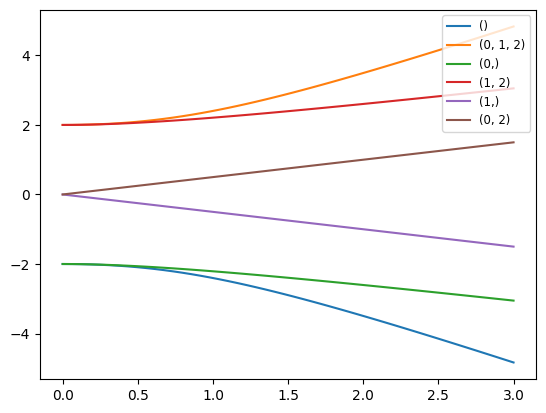

In [70]:
for val in data['energy_exact']:
    plt.plot(chemical_potential_values, data['energy_exact'][val][0], label=str(val))

plt.legend(fontsize='small')
plt.show()